# ch205 — Derivative Concept

**Part VII: Calculus**

---

## 1. The Definition

The **derivative** of f at a point x is defined as the limit of the difference quotient:

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

This limit *(introduced in ch203 — Limits Intuition)* may or may not exist. When it exists, f is called **differentiable** at x.

The derivative is not a number — it is a **function** that tells you the instantaneous rate of change of f at every point where the limit exists.

The notation f'(x) is due to Leibniz's alternative: df/dx. Both are standard. In this book we use f'(x) for clarity.

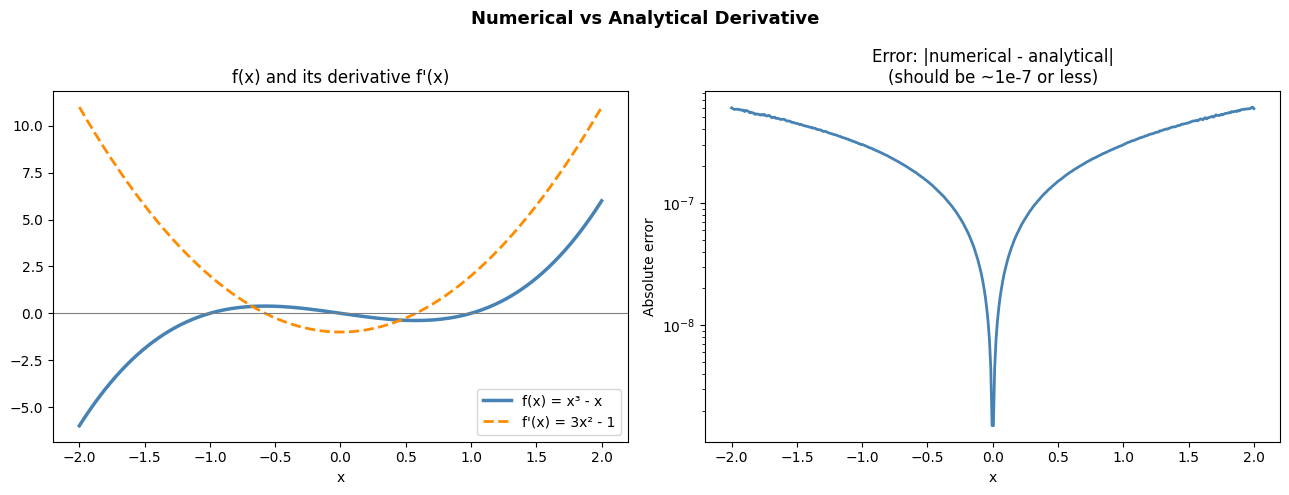

Max error across x ∈ [-2, 2]: 6.08e-07


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the derivative of f(x) = x^3 - x numerically and compare to analytical
f   = lambda x: x**3 - x
fp  = lambda x: 3*x**2 - 1  # analytical: d/dx (x^3 - x) = 3x^2 - 1

def numerical_derivative(f, x, h=1e-7):
    """Forward difference: [f(x+h) - f(x)] / h"""
    return (f(x + h) - f(x)) / h

x_vals = np.linspace(-2, 2, 400)

f_vals      = f(x_vals)
fp_exact    = fp(x_vals)
fp_numerical= numerical_derivative(f, x_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Function and its derivative
axes[0].plot(x_vals, f_vals, color='steelblue', linewidth=2.5, label='f(x) = x³ - x')
axes[0].plot(x_vals, fp_exact, color='darkorange', linewidth=2, linestyle='--', label="f'(x) = 3x² - 1")
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_title('f(x) and its derivative f\'(x)')
axes[0].legend()
axes[0].set_xlabel('x')

# Error between numerical and analytical
error = np.abs(fp_numerical - fp_exact)
axes[1].semilogy(x_vals, error + 1e-20, color='steelblue', linewidth=2)
axes[1].set_title('Error: |numerical - analytical|\n(should be ~1e-7 or less)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Absolute error')

plt.suptitle('Numerical vs Analytical Derivative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Max error across x ∈ [-2, 2]: {error.max():.2e}')

## 2. Differentiation Rules

Rather than computing the limit every time, we use rules derived from the limit definition:

| Rule | Formula |
|------|---------|
| Power rule | d/dx xⁿ = n·xⁿ⁻¹ |
| Constant | d/dx c = 0 |
| Sum | d/dx [f+g] = f' + g' |
| Product | d/dx [f·g] = f'g + fg' |
| Chain rule | d/dx f(g(x)) = f'(g(x))·g'(x) |
| Exponential | d/dx eˣ = eˣ |
| Logarithm | d/dx ln(x) = 1/x |
| Sine / Cosine | d/dx sin(x) = cos(x), d/dx cos(x) = -sin(x) |

In [2]:
# Verify each rule numerically
h = 1e-7
numerical = lambda f, x: (f(x + h) - f(x)) / h

test_cases = [
    ('Power: x^4',        lambda x: x**4,          lambda x: 4*x**3,           np.array([1.5, -2.0, 0.5])),
    ('Exp: e^x',          lambda x: np.exp(x),      lambda x: np.exp(x),        np.array([0.0, 1.0, -1.0])),
    ('Log: ln(x)',        lambda x: np.log(x),      lambda x: 1/x,              np.array([0.5, 1.0, 3.0])),
    ('Sin: sin(x)',       lambda x: np.sin(x),      lambda x: np.cos(x),        np.array([0.0, np.pi/4, np.pi])),
    ('Product: x²·sin(x)',lambda x: x**2*np.sin(x), lambda x: 2*x*np.sin(x)+x**2*np.cos(x), np.array([1.0, 2.0])),
    ('Chain: sin(x²)',    lambda x: np.sin(x**2),   lambda x: 2*x*np.cos(x**2), np.array([1.0, 0.5])),
]

print(f'{"Rule":<25} {"x":>6}  {"Numerical":>14}  {"Analytical":>14}  {"Error":>10}')
print('-' * 78)

for name, f, fp_exact_fn, xs in test_cases:
    for x in xs:
        num = numerical(f, x)
        exact = fp_exact_fn(x)
        err = abs(num - exact)
        print(f'{name:<25} {x:>6.2f}  {num:>14.8f}  {exact:>14.8f}  {err:>10.2e}')

Rule                           x       Numerical      Analytical       Error
------------------------------------------------------------------------------
Power: x^4                  1.50     13.50000136     13.50000000    1.36e-06
Power: x^4                 -2.00    -31.99999762    -32.00000000    2.38e-06
Power: x^4                  0.50      0.50000015      0.50000000    1.50e-07
Exp: e^x                    0.00      1.00000005      1.00000000    4.94e-08
Exp: e^x                    1.00      2.71828197      2.71828183    1.40e-07
Exp: e^x                   -1.00      0.36787946      0.36787944    1.79e-08
Log: ln(x)                  0.50      1.99999980      2.00000000    2.01e-07
Log: ln(x)                  1.00      0.99999995      1.00000000    4.94e-08
Log: ln(x)                  3.00      0.33333333      0.33333333    7.95e-09
Sin: sin(x)                 0.00      1.00000000      1.00000000    1.67e-15
Sin: sin(x)                 0.79      0.70710674      0.70710678    3.69e-

## 3. Where Derivatives Don't Exist

Not every function is differentiable everywhere. Sharp corners, discontinuities, and vertical tangents are the common failure modes.

In machine learning, the ReLU activation function *(introduced in ch065 — Activation Functions in ML)* has a non-differentiable point at x=0. Practitioners use a **subgradient** (a generalization) at that point.

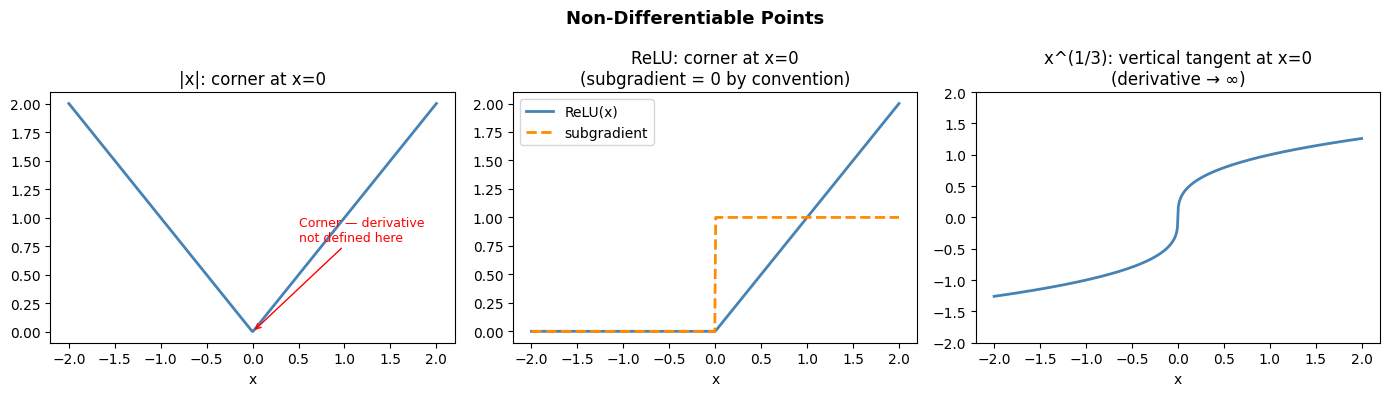

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. |x| — not differentiable at 0 (corner)
x = np.linspace(-2, 2, 400)
axes[0].plot(x, np.abs(x), color='steelblue', linewidth=2, label='|x|')
# Left derivative = -1, right derivative = +1
axes[0].annotate('Corner — derivative\nnot defined here', xy=(0, 0), xytext=(0.5, 0.8),
                 arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
axes[0].set_title('|x|: corner at x=0')
axes[0].set_xlabel('x')

# 2. ReLU — derivative is 0 for x<0, 1 for x>0, undefined at 0
relu = lambda x: np.maximum(0, x)
drelu_subgrad = lambda x: np.where(x > 0, 1.0, 0.0)  # standard subgradient convention
axes[1].plot(x, relu(x), color='steelblue', linewidth=2, label='ReLU(x)')
axes[1].plot(x, drelu_subgrad(x), color='darkorange', linewidth=2, linestyle='--', label='subgradient')
axes[1].set_title('ReLU: corner at x=0\n(subgradient = 0 by convention)')
axes[1].set_xlabel('x')
axes[1].legend()

# 3. x^(1/3) — vertical tangent at 0
x3 = np.linspace(-2, 2, 400)
x3_nonzero = x3[x3 != 0]
cbrt = np.cbrt(x3)
dcbrt = np.where(x3 != 0, (1/3) * np.abs(x3)**(-2/3) * np.sign(x3), np.inf)
axes[2].plot(x3, cbrt, color='steelblue', linewidth=2, label='x^(1/3)')
axes[2].set_ylim(-2, 2)
axes[2].set_title('x^(1/3): vertical tangent at x=0\n(derivative → ∞)')
axes[2].set_xlabel('x')

plt.suptitle('Non-Differentiable Points', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. The Derivative as a Function

The derivative f'(x) is itself a function. We can ask about its properties:
- Where is f'(x) = 0? (stationary points — potential minima/maxima)
- Where is f'(x) > 0? (f is increasing)
- Where is f'(x) < 0? (f is decreasing)

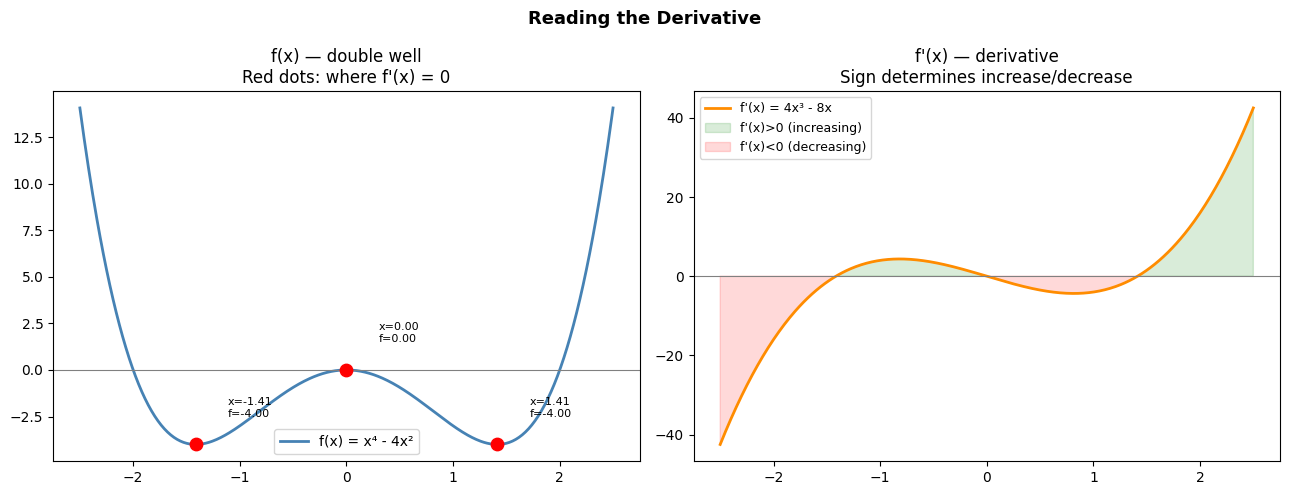

Stationary points (where f'(x) = 0):
  x = 0    (local maximum): f(0) = 0
  x = ±√2 (local minima):  f(±√2) = -4.0000


In [4]:
# f(x) = x^4 - 4x^2 (a double-well potential, common in physics and ML loss landscapes)
f   = lambda x: x**4 - 4*x**2
fp  = lambda x: 4*x**3 - 8*x

x = np.linspace(-2.5, 2.5, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Annotate increasing/decreasing regions
axes[0].plot(x, f(x), color='steelblue', linewidth=2, label='f(x) = x⁴ - 4x²')
# Stationary points: f'(x) = 0 => 4x(x^2 - 2) = 0 => x = 0, ±√2
stationary = [0, np.sqrt(2), -np.sqrt(2)]
for xs in stationary:
    axes[0].scatter([xs], [f(xs)], color='red', zorder=6, s=80)
    axes[0].annotate(f'x={xs:.2f}\nf={f(xs):.2f}', xy=(xs, f(xs)),
                     xytext=(xs + 0.3, f(xs) + 1.5), fontsize=8)
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_title('f(x) — double well\nRed dots: where f\'(x) = 0')
axes[0].legend()

axes[1].plot(x, fp(x), color='darkorange', linewidth=2, label="f'(x) = 4x³ - 8x")
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].fill_between(x, fp(x), 0, where=fp(x) > 0, alpha=0.15, color='green', label="f'(x)>0 (increasing)")
axes[1].fill_between(x, fp(x), 0, where=fp(x) < 0, alpha=0.15, color='red', label="f'(x)<0 (decreasing)")
axes[1].set_title("f'(x) — derivative\nSign determines increase/decrease")
axes[1].legend(fontsize=9)

plt.suptitle('Reading the Derivative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Stationary points (where f\'(x) = 0):')
print(f'  x = 0    (local maximum): f(0) = {f(0)}')
print(f'  x = ±√2 (local minima):  f(±√2) = {f(np.sqrt(2)):.4f}')

## 5. Summary

- The derivative f'(x) = lim(h→0) [f(x+h)-f(x)]/h is the instantaneous rate of change
- Differentiation rules (power, product, chain) are derived from this limit
- Numerical derivatives approximate the limit with finite h; optimal h ≈ 1e-7
- Derivatives can fail to exist at corners, discontinuities, and vertical tangents
- Where f'(x) = 0: stationary points (potential optima); sign of f'(x) tells you increase/decrease

---

## 6. Forward References

The tangent line interpretation is developed geometrically in ch206 — Tangent Lines. The chain rule *(listed in the table above)* becomes central in ch215 — Chain Rule and ch216 — Backpropagation Intuition. The stationary point analysis above is extended to multiple dimensions in ch209 — Gradient Intuition and ch212 — Gradient Descent.